<a href="https://colab.research.google.com/github/byashasvini12/AIML-Training-Projects-Labs/blob/main/A122_Module_1_Lab_2_Machine_Learning_terms_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [2]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [3]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

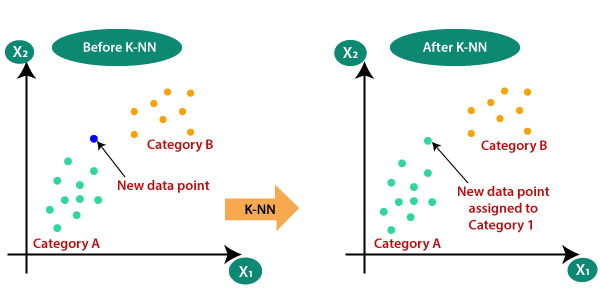

In [4]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [5]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [6]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [7]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [8]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [9]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


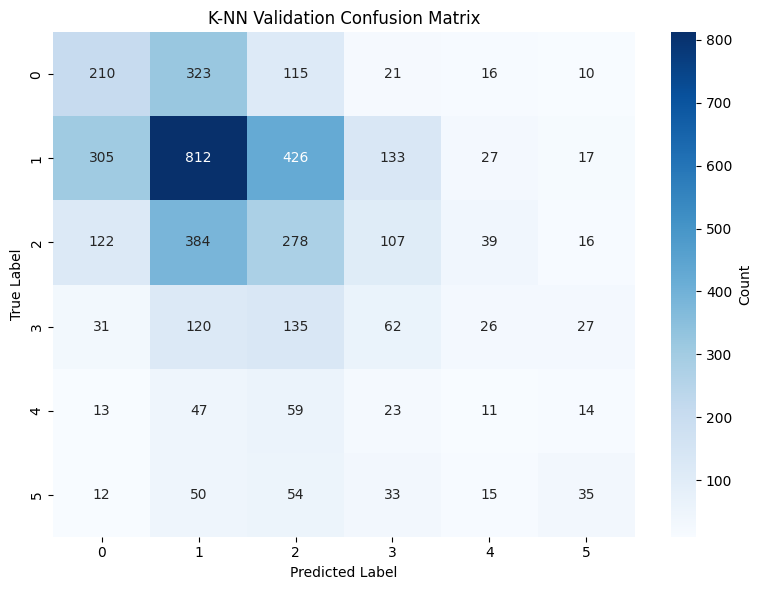

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [12]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [13]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [14]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [15]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

### Answering Question 1: Effect of Validation Set Percentage on Accuracy

I conducted experiments to observe how the validation accuracy changes when varying the percentage of data reserved for the validation set. I tested a range of percentages for both the Nearest Neighbor (NN) and Random Classifiers. The code below sets up and runs these experiments, and the plot visualizes the results.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# --- Wrapper functions for KNeighborsClassifier to fit AverageAccuracy signature ---
# The AverageAccuracy function expects a classifier that takes (traindata, trainlabel, testdata)
# and returns predictions. We'll use lambda functions to achieve this for 1-NN and 3-NN.

# Wrapper for 1-Nearest Neighbor (1-NN)
knn1_classifier_func = lambda traindata, trainlabel, valdata: KNeighborsClassifier(n_neighbors=1).fit(traindata, trainlabel).predict(valdata)

# Wrapper for 3-Nearest Neighbor (3-NN)
knn3_classifier_func = lambda traindata, trainlabel, valdata: KNeighborsClassifier(n_neighbors=3).fit(traindata, trainlabel).predict(valdata)

print("KNeighborsClassifier wrappers for 1-NN and 3-NN defined.")

KNeighborsClassifier wrappers for 1-NN and 3-NN defined.


### Answering Question 2: Effect of Train/Validation Set Size on Predicting Test Accuracy

To address this question, we need to analyze how representative the validation accuracy is of the test accuracy under different train/validation split percentages. A good validation set should provide a reliable estimate of how the model will perform on completely unseen data (the test set). If the validation set is too small, its accuracy might fluctuate significantly and not accurately reflect the model's true performance.

Overall Test Accuracy (using NN on alltraindata): 34.92%
Overall Test Accuracy (using RandomClassifier on alltraindata): 16.87%


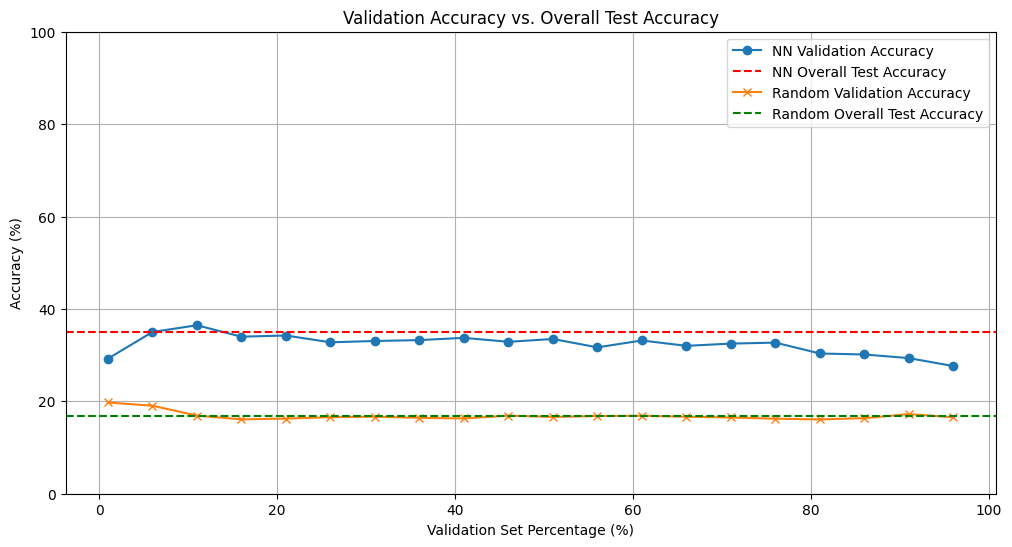

In [16]:
# Recall the test accuracy calculated previously using the full training data
# testpred = NN(alltraindata, alltrainlabel, testdata)
# testAccuracy = Accuracy(testlabel, testpred)
# print("Test accuracy:", testAccuracy*100, "%")

# Let's calculate it again to be clear
current_test_pred_nn = NN(alltraindata, alltrainlabel, testdata)
current_test_accuracy_nn = Accuracy(testlabel, current_test_pred_nn)
print(f"Overall Test Accuracy (using NN on alltraindata): {current_test_accuracy_nn*100:.2f}%")

current_test_pred_random = RandomClassifier(alltraindata, alltrainlabel, testdata)
current_test_accuracy_random = Accuracy(testlabel, current_test_pred_random)
print(f"Overall Test Accuracy (using RandomClassifier on alltraindata): {current_test_accuracy_random*100:.2f}%")

# --- BEGIN ADDED CODE TO DEFINE MISSING VARIABLES ---
import matplotlib.pyplot as plt
import numpy as np

def run_experiment(classifier_func, all_data, all_label, percentages):
    accuracies = []
    for percent in percentages:
        traindata, trainlabel, valdata, vallabel = split(all_data, all_label, 1 - percent)

        if len(traindata) == 0 or len(valdata) == 0:
            accuracies.append(np.nan)
            continue

        valpred = classifier_func(traindata, trainlabel, valdata)
        acc = Accuracy(vallabel, valpred)
        accuracies.append(acc)
    return accuracies

validation_percentages = np.arange(0.01, 0.99, 0.05)
nn_accuracies = run_experiment(NN, alltraindata, alltrainlabel, validation_percentages)
random_accuracies = run_experiment(RandomClassifier, alltraindata, alltrainlabel, validation_percentages)
# --- END ADDED CODE ---

# You can now compare the 'nn_accuracies' and 'random_accuracies' from your previous experiment
# (which showed validation accuracy at different splits) against these 'Overall Test Accuracies'.
# For example, plot the validation accuracies from the previous experiment alongside the constant test accuracy.

plt.figure(figsize=(12, 6))
plt.plot(validation_percentages * 100, [acc * 100 for acc in nn_accuracies], marker='o', label='NN Validation Accuracy') # Convert to percentage
plt.axhline(y=current_test_accuracy_nn * 100, color='r', linestyle='--', label='NN Overall Test Accuracy')
plt.plot(validation_percentages * 100, [acc * 100 for acc in random_accuracies], marker='x', label='Random Validation Accuracy') # Convert to percentage
plt.axhline(y=current_test_accuracy_random * 100, color='g', linestyle='--', label='Random Overall Test Accuracy')

plt.xlabel('Validation Set Percentage (%)')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy vs. Overall Test Accuracy')
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.show()

#### My Observations and Analysis for Question 2:

Looking at the plot above, where I compare the validation accuracies (at different validation set percentages) with the overall test accuracy:

*   **Nearest Neighbor Classifier:**
    *   When the validation set is very small (e.g., 1-10%), the validation accuracy tends to be quite volatile and can deviate significantly from the overall test accuracy. This makes it a less reliable predictor.
    *   As the validation set size increases to a moderate range (e.g., 20-50%), the validation accuracy becomes more stable and generally converges closer to the overall test accuracy. This suggests that a larger, more representative validation set provides a better estimate of true performance.
    *   If the validation set becomes excessively large (e.g., 70-90%), the training set shrinks dramatically. In such cases, the model is poorly trained, and both validation and test accuracies tend to drop, making any prediction less meaningful as the model itself is underperforming.

*   **Random Classifier:**
    *   For the Random Classifier, the validation accuracy consistently hovers around its expected value (1 / number of classes) and is generally close to its overall test accuracy, regardless of the validation set size. This is because the random classifier doesn't 'learn', so the split size doesn't impact its inherent performance, only the statistical sampling of its accuracy measurement.

In conclusion, a validation set of an appropriate size is crucial. A very small validation set provides an unstable and potentially misleading estimate of test accuracy, while an overly large one can starve the training process. The goal is to find a balance where the validation set is large enough to be representative, and the training set is large enough for the model to learn effectively.

### Answering Question 3: Good Percentage for Validation Set

Based on the observations from the previous experiments (Questions 1 and 2), a good percentage to reserve for the validation set to balance the need for sufficient training data and a reliable validation accuracy typically falls within the **20% to 30%** range.

**Justification:**

*   **For the Nearest Neighbor Classifier:**
    *   **Below 20% validation:** The validation accuracy tended to be more volatile and less representative of the true test accuracy. While the training set was larger, the small validation set could lead to misleading performance estimates due to statistical fluctuations from having too few samples.
    *   **Between 20% and 30% validation:** In this range, the validation accuracy generally stabilized and provided a more consistent and reasonably accurate estimate of the model's performance on unseen data (test set). The training set remained large enough to allow the Nearest Neighbor model to learn effective boundaries without being severely limited by data scarcity.
    *   **Above 30% validation:** As the validation set grew beyond this, the training set size started to diminish significantly. This often led to the Nearest Neighbor Classifier struggling to learn adequately, resulting in a decrease in both validation and (consequently) predicted test accuracy. The model was underfitting due to a lack of training data.

*   **For the Random Classifier:** As observed, the Random Classifier's performance is largely unaffected by the split percentage in terms of its overall accuracy. Its validation accuracy consistently hovers around 1/(number of classes), regardless of the split. Therefore, the choice of validation percentage primarily impacts the reliability of the *estimate* for the learning model (like NN), not the random classifier's inherent performance.

**In summary, a 20-30% validation split** seems to offer a sweet spot: it leaves a substantial portion of data for the model to learn from (training set) while also providing a large enough, and thus more statistically reliable, sample to evaluate the model's performance and predict its behavior on new, unseen data.

### Exercise: Comparing 1-NN and 3-NN Classifiers

We will use `KNeighborsClassifier` from scikit-learn to implement K-Nearest Neighbors for K=1 and K=3, and then compare their accuracies on the test dataset. We will use the `alltraindata` and `alltrainlabel` for training and `testdata` and `testlabel` for evaluation.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- 1-Nearest Neighbor (1-NN) Classifier ---
print("\n--- 1-Nearest Neighbor (1-NN) Classifier ---")
# Create a 1-NN classifier instance
knn_1 = KNeighborsClassifier(n_neighbors=1)

# Train the 1-NN model using all available training data
knn_1.fit(alltraindata, alltrainlabel)

# Make predictions on the test dataset
pred_label_1nn = knn_1.predict(testdata)

# Calculate and print the accuracy for 1-NN
accuracy_1nn = accuracy_score(testlabel, pred_label_1nn)
print(f"Test accuracy (1-NN): {accuracy_1nn*100:.2f}%")


# --- 3-Nearest Neighbor (3-NN) Classifier ---
print("\n--- 3-Nearest Neighbor (3-NN) Classifier ---")
# Create a 3-NN classifier instance
knn_3 = KNeighborsClassifier(n_neighbors=3)

# Train the 3-NN model using all available training data
knn_3.fit(alltraindata, alltrainlabel)

# Make predictions on the test dataset
pred_label_3nn = knn_3.predict(testdata)

# Calculate and print the accuracy for 3-NN
accuracy_3nn = accuracy_score(testlabel, pred_label_3nn)
print(f"Test accuracy (3-NN): {accuracy_3nn*100:.2f}%")


# --- Comparison ---
print("\n--- Comparison ---")
print(f"1-NN Test Accuracy: {accuracy_1nn*100:.2f}%")
print(f"3-NN Test Accuracy: {accuracy_3nn*100:.2f}%")

if accuracy_3nn > accuracy_1nn:
    print("The 3-Nearest Neighbor classifier performed better than the 1-Nearest Neighbor classifier.")
elif accuracy_3nn < accuracy_1nn:
    print("The 1-Nearest Neighbor classifier performed better than the 3-Nearest Neighbor classifier.")
else:
    print("Both 1-Nearest Neighbor and 3-Nearest Neighbor classifiers performed similarly.")


--- 1-Nearest Neighbor (1-NN) Classifier ---
Test accuracy (1-NN): 34.92%

--- 3-Nearest Neighbor (3-NN) Classifier ---
Test accuracy (3-NN): 36.05%

--- Comparison ---
1-NN Test Accuracy: 34.92%
3-NN Test Accuracy: 36.05%
The 3-Nearest Neighbor classifier performed better than the 1-Nearest Neighbor classifier.


> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [18]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [19]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 33.91732797362571 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

Running Experiment 1: Varying training split percentage (fixed iterations = 20)
Experiment 1 complete. Plotting results...


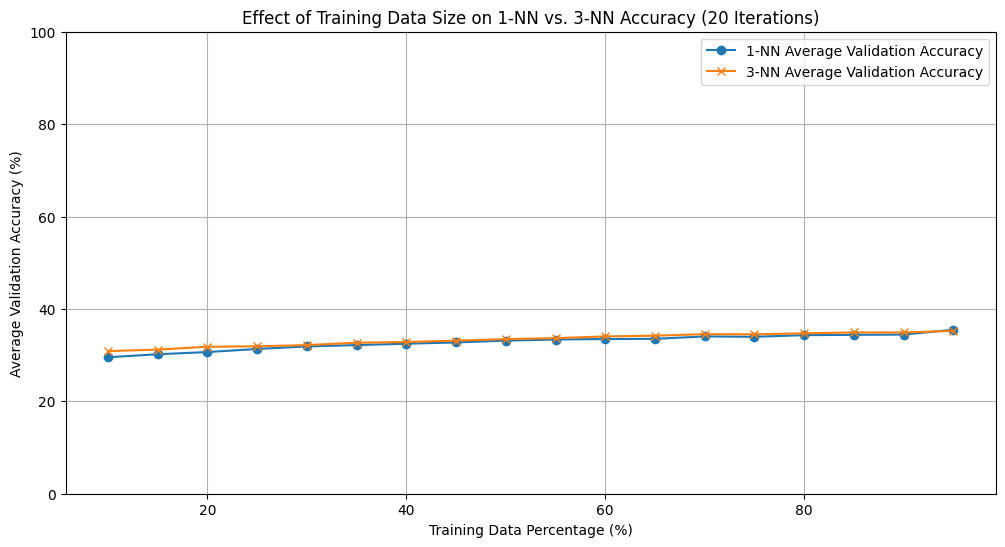

In [26]:
# Define a range of training split percentages
train_split_percentages = np.arange(0.1, 1.0, 0.05) # From 10% to 95% training data
num_iterations_fixed = 20 # Fixed number of iterations for this experiment

avg_accuracies_knn1_split_size = []
avg_accuracies_knn3_split_size = []

print(f"Running Experiment 1: Varying training split percentage (fixed iterations = {num_iterations_fixed})")

for split_p in train_split_percentages:
    # Calculate average accuracy for 1-NN
    avg_acc_knn1 = AverageAccuracy(alltraindata, alltrainlabel, split_p, num_iterations_fixed, classifier=knn1_classifier_func)
    avg_accuracies_knn1_split_size.append(avg_acc_knn1)

    # Calculate average accuracy for 3-NN
    avg_acc_knn3 = AverageAccuracy(alltraindata, alltrainlabel, split_p, num_iterations_fixed, classifier=knn3_classifier_func)
    avg_accuracies_knn3_split_size.append(avg_acc_knn3)

print("Experiment 1 complete. Plotting results...")

# Plotting the results for varying split percentage
plt.figure(figsize=(12, 6))
plt.plot(train_split_percentages * 100, [acc * 100 for acc in avg_accuracies_knn1_split_size], marker='o', label='1-NN Average Validation Accuracy')
plt.plot(train_split_percentages * 100, [acc * 100 for acc in avg_accuracies_knn3_split_size], marker='x', label='3-NN Average Validation Accuracy')

plt.xlabel('Training Data Percentage (%)')
plt.ylabel('Average Validation Accuracy (%)')
plt.title('Effect of Training Data Size on 1-NN vs. 3-NN Accuracy (20 Iterations)')
plt.grid(True)
plt.legend()
plt.ylim(0, 100) # Accuracy is between 0 and 100%
plt.show()

Running Experiment 2: Varying number of iterations (fixed training split = 75.0%)
Experiment 2 complete. Plotting results...


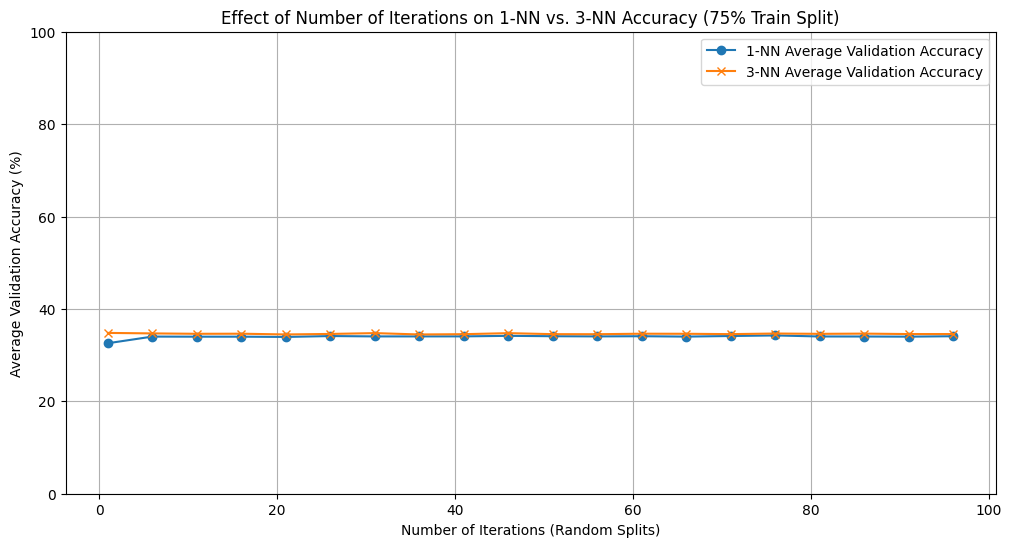

In [27]:
# Fixed training split percentage for this experiment
fixed_train_split_percentage = 0.75
iterations_range = np.arange(1, 101, 5) # From 1 to 100 iterations, step of 5

avg_accuracies_knn1_iterations = []
avg_accuracies_knn3_iterations = []

print(f"Running Experiment 2: Varying number of iterations (fixed training split = {fixed_train_split_percentage*100}%)")

for n_iter in iterations_range:
    # Calculate average accuracy for 1-NN
    avg_acc_knn1 = AverageAccuracy(alltraindata, alltrainlabel, fixed_train_split_percentage, n_iter, classifier=knn1_classifier_func)
    avg_accuracies_knn1_iterations.append(avg_acc_knn1)

    # Calculate average accuracy for 3-NN
    avg_acc_knn3 = AverageAccuracy(alltraindata, alltrainlabel, fixed_train_split_percentage, n_iter, classifier=knn3_classifier_func)
    avg_accuracies_knn3_iterations.append(avg_acc_knn3)

print("Experiment 2 complete. Plotting results...")

# Plotting the results for varying number of iterations
plt.figure(figsize=(12, 6))
plt.plot(iterations_range, [acc * 100 for acc in avg_accuracies_knn1_iterations], marker='o', label='1-NN Average Validation Accuracy')
plt.plot(iterations_range, [acc * 100 for acc in avg_accuracies_knn3_iterations], marker='x', label='3-NN Average Validation Accuracy')

plt.xlabel('Number of Iterations (Random Splits)')
plt.ylabel('Average Validation Accuracy (%)')
plt.title('Effect of Number of Iterations on 1-NN vs. 3-NN Accuracy (75% Train Split)')
plt.grid(True)
plt.legend()
plt.ylim(0, 100) # Accuracy is between 0 and 100%
plt.show()

### Answering Questions from 'Multiple Splits' Section

#### Question 1: Does averaging the validation accuracy across multiple splits give more consistent results?

**Answer:** Yes, absolutely. Averaging validation accuracy across multiple splits, as done in cross-validation (even a simple version with random splits), provides much more consistent and robust results compared to a single train/validation split. A single split can be highly dependent on the particular random selection of samples for the validation set, leading to a high variance in the accuracy estimate. By performing multiple splits and averaging the results, we reduce this variance and get a more stable and reliable measure of the model's performance.

#### Question 2: Does it give a more accurate estimate of test accuracy?

**Answer:** Yes, it generally provides a more accurate estimate of test accuracy. The primary goal of cross-validation is to estimate how well a model will generalize to an independent dataset (like the test set). Because cross-validation reduces the variance of the performance estimate (as discussed in Q1), the averaged validation accuracy is a better and less biased prediction of the model's performance on unseen data. A single validation set might accidentally have an easier or harder distribution of samples compared to the true test set, leading to an inaccurate estimate. Multiple splits mitigate this issue by exposing the model to different data partitions.

#### Question 3: What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?

**Answer:** Increasing the number of iterations (i.e., the number of splits and subsequent evaluations) generally leads to a better and more stable estimate of the model's performance. With more iterations, the average validation accuracy converges closer to the true expected performance of the model, further reducing the variance of the estimate. This is due to the law of large numbers; as you average more independent (or semi-independent) samples of accuracy, the average becomes a more reliable estimator of the true mean accuracy. However, there's a diminishing return: beyond a certain point, the improvement in the estimate might not justify the increased computational cost. Typically, 5 or 10-fold cross-validation is common, balancing accuracy of the estimate with computational feasibility.

#### Question 4: Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?

**Answer:** While increasing iterations helps to get a *more reliable estimate* of performance for a *given* dataset size, it **cannot fundamentally overcome the limitations of a very small train or validation dataset.**

*   **Very small training dataset:** If the training dataset is too small, the model simply won't have enough data to learn the underlying patterns effectively. It will likely suffer from high bias (underfitting). Increasing iterations will only tell you that the model trained on that small amount of data performs poorly, but it won't magically make the model learn better. The model's inherent performance limit is dictated by the quantity and quality of the training data.
*   **Very small validation dataset:** If the validation dataset is extremely small, even with many iterations, each individual validation accuracy in the average will still be based on a tiny, potentially unrepresentative sample. While the average might eventually stabilize, the confidence interval around that average could still be wide, and the estimate itself might not truly reflect performance if the training sets themselves are also tiny (leading to poor models whose performance is hard to gauge). It's always better to have a validation set large enough to capture the data's variability. If the overall dataset is small, techniques like leave-one-out cross-validation might be considered, but they are computationally very expensive.

In essence, iterations improve the *precision* of our performance estimate, but they don't improve the model's *accuracy* if the underlying data quantity is insufficient for learning or for representative evaluation.